# **Data analysis on comments**

This notebook runs a bunch of data analysis on the comments and saves the analysis to `data/processed/comments`.

In [ ]:
import sys
import subprocess


subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--upgrade",
    "pandas",
    "plotly",
    "wordcloud",
    "matplotlib",
    "numpy",
    "kaleido",
    "pyarrow"
])

# Imports and setup

In [31]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.pyplot as plt  
from pathlib import Path
import json
import plotly.io as pio

df = pd.read_parquet('../data/comments.parquet')
index = {
    "numerical":{},
    "top":{},
    "graphs":{},
}

In [12]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head()

Dataset shape: (1323, 5)

Columns: ['text', 'devlog_id', 'slack_id', 'created_at', 'scraped_at']

Data types:
text                       object
devlog_id                   int64
slack_id                   object
created_at    datetime64[ns, UTC]
scraped_at    datetime64[ns, UTC]
dtype: object

First few rows:


,text,devlog_id,slack_id,created_at,scraped_at
0,"woow, pretty awesome project! i love it!",7,U06MC0G7A4R,2025-06-16 05:37:49.240000+00:00,2025-08-15 04:09:34.853000+00:00
1,"ngl, this looks really cool!",41,U05F4B48GBF,2025-06-16 17:38:34.630000+00:00,2025-08-15 04:09:34.853000+00:00
2,"Love the design, amazing work",48,U079W50D0Q2,2025-06-16 18:09:06.660000+00:00,2025-08-15 04:09:34.853000+00:00
3,This is the exact project I am working on haha...,55,U08FAMN2MAP,2025-06-16 18:39:42.904000+00:00,2025-08-15 04:09:34.853000+00:00
4,"is it, I would love to compete..feel free to d...",55,U091PSK9RB6,2025-06-16 18:45:18.801000+00:00,2025-08-15 04:09:34.853000+00:00


In [33]:
EXPORT_DIR = Path('../data/processed/comments').resolve()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_WIDTH = 1100
DEFAULT_HEIGHT = 420

som_wide = go.layout.Template(layout=dict(
    width=DEFAULT_WIDTH,
    margin=dict(l=60, r=30, t=60, b=50),
))
pio.templates['som_wide'] = som_wide
pio.templates.default = 'plotly_white+som_wide'

try:
    pio.renderers.default = 'vscode'
except Exception:
    pass


def register_graph(key: str,name:str, description: str, image_file: str):
    index['graphs'][key] = {
        'name': name,
        'description': description,
        'image_file': Path(image_file).name
    }

def save_plotly(fig, name: str, description: str, scale: int = 2, width=None, height=None, friendly_name: str = ""):
    filename = f"{name}.png"
    out_path = EXPORT_DIR / filename
    try:
        exp_width = width if width is not None else (fig.layout.width or DEFAULT_WIDTH)
        exp_height = height if height is not None else (fig.layout.height or DEFAULT_HEIGHT)
        fig.write_image(str(out_path), scale=scale, width=exp_width,
                        height=exp_height)
        register_graph(name,friendly_name, description, filename)
    except Exception as e:
        print(f'Failed to save Plotly figure {name}: {e}')


def save_matplotlib_current(name: str, description: str, dpi: int = 150, friendly_name: str = ""):
    filename = f"{name}.png"
    out_path = EXPORT_DIR / filename
    try:
        plt.gcf().savefig(out_path, bbox_inches='tight', dpi=dpi, facecolor='white')
        register_graph(name, friendly_name, description, filename)
    except Exception as e:
        print(f'Failed to save Matplotlib figure {name}: {e}')

def save_to_index(key: str,name:str,description:str, data, type="numerical"):
    if isinstance(data, pd.DataFrame):
        records = data.to_dict(orient='records')
        indexed = {i: rec for i, rec in enumerate(records)}
        index[type][key] = {
            'name': name,
            'description': description,
            'data': indexed,
        }
    else:
        index[type][key] = {
            'name': name,
            'description': description,
            'data': data
        }

# **Numerical data**
Shows some numerical data

### Total number of comments

Count the total number of comments in the dataset.

In [34]:
total_comments = len(df)
print(f"Total number of comments: {total_comments:,}")

save_to_index('total_comments', name='Total number of comments', description='The total number of comments in the dataset.', data=int(total_comments), type='numerical')

Total number of comments: 1,367


### Number of unique devlogs with comments

Count how many unique devlogs have comments.

In [35]:
unique_devlogs = df['devlog_id'].nunique()
print(f"Number of unique devlogs with comments: {unique_devlogs:,}")

save_to_index('unique_devlogs_with_comments', name='Unique devlogs with comments', description='The number of unique devlogs that have comments.', data=int(unique_devlogs), type='numerical')

Number of unique devlogs with comments: 988


### Number of unique users who commented

Count how many unique users have made comments.

In [36]:
unique_users = df['slack_id'].nunique()
print(f"Number of unique users who commented: {unique_users:,}")

save_to_index('unique_commenting_users', name='Unique commenting users', description='The number of unique users who have made comments.', data=int(unique_users), type='numerical')

Number of unique users who commented: 559


### Average comments per devlog

Calculate the average number of comments per devlog.

In [37]:
avg_comments_per_devlog = total_comments / unique_devlogs
print(f"Average comments per devlog: {avg_comments_per_devlog:.2f}")

save_to_index('avg_comments_per_devlog', name='Average comments per devlog', description='The average number of comments per devlog.', data=float(avg_comments_per_devlog), type='numerical')

Average comments per devlog: 1.38


### Average comment length

Calculate the average length of comments in characters.

In [38]:
df['text_length'] = df['text'].fillna('').astype(str).str.len()
avg_comment_length = df['text_length'].mean()
print(f"Average comment length: {avg_comment_length:.1f} characters")

save_to_index('avg_comment_length', name='Average comment length', description='The average length of comments in characters.', data=float(avg_comment_length), type='numerical')

Average comment length: 67.6 characters


# **Top stuff**

Shows the top stuff

### Top 5 devlogs by comment count

Show the top 5 devlogs with the most comments.

In [39]:
top_devlogs = (df.groupby('devlog_id')
               .agg({'text': 'count', 'created_at': 'min'})
               .rename(columns={'text': 'comment_count'})
               .sort_values('comment_count', ascending=False)
               .head(5)
               .reset_index())

top_devlogs['devlog_link'] = top_devlogs['devlog_id'].apply(
    lambda x: f"https://summer.hackclub.com/devlogs/{x}")

print("Top 5 devlogs by comment count:")

save_to_index('top_devlogs_by_comments', name='Top 5 devlogs by comment count',
              description='The top 5 devlogs with the most comments.', data=top_devlogs, type='top')
top_devlogs

Top 5 devlogs by comment count:


,devlog_id,comment_count,created_at,devlog_link
0,35559,11,2025-08-13 18:12:47.438000+00:00,https://summer.hackclub.com/devlogs/35559
1,563,8,2025-06-19 21:36:15.991000+00:00,https://summer.hackclub.com/devlogs/563
2,31905,7,2025-08-08 00:07:50.947000+00:00,https://summer.hackclub.com/devlogs/31905
3,35671,7,2025-08-13 21:59:28.874000+00:00,https://summer.hackclub.com/devlogs/35671
4,5868,5,2025-06-24 15:00:03.133000+00:00,https://summer.hackclub.com/devlogs/5868


### Top 5 users by comment count

Show the top 5 users who have made the most comments.

In [40]:
top_users = (df.groupby('slack_id')
             .agg({'text': 'count', 'created_at': 'min'})
             .rename(columns={'text': 'comment_count'})
             .sort_values('comment_count', ascending=False)
             .head(5)
             .reset_index())

top_users['user_profile'] = top_users['slack_id'].apply(
    lambda x: f"Slack ID: {x}")

print("Top 5 users by comment count:")

save_to_index('top_users_by_comments', name='Top 5 users by comment count',
              description='The top 5 users who have made the most comments.', data=top_users, type='top')
top_users

Top 5 users by comment count:


,slack_id,comment_count,created_at,user_profile
0,U07E8H9A24A,36,2025-06-25 16:42:23.507000+00:00,Slack ID: U07E8H9A24A
1,U0925Q3PB0Q,30,2025-07-31 08:45:16.240000+00:00,Slack ID: U0925Q3PB0Q
2,U09A3GV54QL,30,2025-08-12 19:30:48.410000+00:00,Slack ID: U09A3GV54QL
3,U091KJSPK6X,25,2025-06-18 13:44:27.637000+00:00,Slack ID: U091KJSPK6X
4,U080V8UG5BR,21,2025-07-31 14:20:15.173000+00:00,Slack ID: U080V8UG5BR


### Top 5 longest comments

Show the top 5 longest comments by character count.

In [41]:
longest_comments = (df.nlargest(5, 'text_length')[['devlog_id', 'slack_id', 'text_length', 'text', 'created_at']]
                    .copy())

longest_comments['text_preview'] = longest_comments['text'].astype(str).str.slice(0, 100) + '...'
longest_comments['devlog_link'] = longest_comments['devlog_id'].apply(
    lambda x: f"https://summer.hackclub.com/devlogs/{x}")

print("Top 5 longest comments:")

save_to_index('longest_comments', name='Top 5 longest comments',
              description='The top 5 longest comments by character count.', data=longest_comments, type='top')
longest_comments[['devlog_id', 'slack_id', 'text_length', 'text_preview', 'created_at']]

Top 5 longest comments:


,devlog_id,slack_id,text_length,text_preview,created_at
292,2609,U09232V6XUH,945,"thanks to you both!Regarding the cursor: yes, ...",2025-06-21 15:16:57.979000+00:00
1211,34977,U08PDGDPR0F,874,"so actually, i did not use AI, but here’s what...",2025-08-12 20:11:30.030000+00:00
524,5313,U08L7671TDG,610,Hey ! for the Svelte part; I’m actually not re...,2025-06-25 19:36:48.970000+00:00
94,1177,U091KJSPK6X,578,GL with learning Rust! I nearly finished the R...,2025-06-18 18:54:00.774000+00:00
247,2609,U08P78KTA3C,522,Really cool!Is it intentional that the cursor ...,2025-06-21 00:24:37.816000+00:00


# **Graphical Data**

Shows quite a few graphs on the data

# Comments posted per day

This chart shows the number of comments posted on each date using the `created_at` column.

In [42]:
date_series = pd.to_datetime(df['created_at'], errors='coerce')

counts = (
    pd.DataFrame({'date': date_series.dt.date})
      .dropna(subset=['date'])
      .groupby('date')
      .size()
      .reset_index(name='comment_count')
      .sort_values('date')
)

counts['date'] = pd.to_datetime(counts['date'])
counts['rolling_7d'] = counts['comment_count'].rolling(7, min_periods=1).mean()

fig = px.bar(
    counts, x='date', y='comment_count',
    title='Comments Posted per Day',
    labels={'date': 'Date', 'comment_count': 'Comments'},
    color_discrete_sequence=['#636EFA']
)

fig.add_scatter(
    x=counts['date'], y=counts['rolling_7d'],
    name='7-day average', mode='lines',
    line=dict(color='#EF553B', width=2)
)

fig.update_traces(hovertemplate='Date=%{x|%Y-%m-%d}<br>Comments=%{y}')
fig.update_layout(
    hovermode='x unified', bargap=0.15,
    height=max(DEFAULT_HEIGHT, 420),
    xaxis=dict(title='Date', tickformat='%b %Y',
               showgrid=False, rangeslider=dict(visible=True)),
    yaxis=dict(title='Comments', showgrid=True, gridcolor='rgba(0,0,0,0.08)')
)
fig.show()

save_plotly(fig, name='comments_per_day', description='Number of comments posted per day with 7-day rolling mean', friendly_name='Comments Posted per Day')

# Cumulative comments over time

Growth of total comments across dates.

In [43]:
_ds = pd.to_datetime(df['created_at'], errors='coerce')
series = (
    pd.DataFrame({'date': _ds.dt.date})
      .dropna()
      .groupby('date')
      .size()
      .reset_index(name='count')
      .sort_values('date')
)
series['date'] = pd.to_datetime(series['date'])
series['cumulative'] = series['count'].cumsum()

fig = px.area(series, x='date', y='cumulative',
              title='Cumulative Comments',
              labels={'date': 'Date', 'cumulative': 'Total Comments'},
              color_discrete_sequence=['#19A974'])
fig.update_layout(height=max(DEFAULT_HEIGHT, 420))
fig.show()

save_plotly(fig, name='cumulative_comments', description='Cumulative total of comments over time', friendly_name='Cumulative Comments')

# Distribution of comment lengths

How are comment lengths distributed?

In [44]:
fig = px.histogram(
    df['text_length'], nbins=50,
    title='Distribution of Comment Lengths',
    labels={'value': 'Characters', 'count': 'Comments'},
    color_discrete_sequence=['#636EFA']
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(bargap=0.05,
                  height=max(DEFAULT_HEIGHT - 20, 400),
                  xaxis_title='Characters', yaxis_title='Comments')
fig.show()

save_plotly(fig, name='comment_length_distribution', description='Histogram of comment lengths in characters', friendly_name='Comment Length Distribution')

# Top devlogs and users by comment count

Two horizontal bar charts: top devlogs by comment count and top users by comment count.

In [45]:
TOP_N = 10

devlog_counts = (df.groupby('devlog_id')
                 .size()
                 .sort_values(ascending=False)
                 .head(TOP_N)
                 .reset_index(name='comment_count'))

user_counts = (df.groupby('slack_id')
               .size()
               .sort_values(ascending=False)
               .head(TOP_N)
               .reset_index(name='comment_count'))

devlog_counts['label'] = 'Devlog ' + devlog_counts['devlog_id'].astype(str)
user_counts['label'] = 'User ' + user_counts['slack_id'].astype(str).str.slice(0, 12) + '...'

height = max(len(devlog_counts), len(user_counts)) * 44 + 240

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.5, 0.5],
    subplot_titles=(
        'Top Devlogs by Comment Count',
        'Top Users by Comment Count'
    )
)

fig.add_trace(
    go.Bar(
        x=devlog_counts['comment_count'][::-1],
        y=devlog_counts['label'][::-1],
        orientation='h',
        marker_color='#636EFA',
        hovertemplate='%{y}<br>Comments=%{x}'
    ), row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=user_counts['comment_count'][::-1],
        y=user_counts['label'][::-1],
        orientation='h',
        marker_color='#EF553B',
        hovertemplate='%{y}<br>Comments=%{x}'
    ), row=1, col=2
)

fig.update_layout(
    height=max(DEFAULT_HEIGHT + (len(devlog_counts)*18), height),
    margin=dict(l=220, r=30, t=80, b=40),
    showlegend=False,
    bargap=0.25
)
fig.update_xaxes(title_text='Comments', row=1, col=1)
fig.update_xaxes(title_text='Comments', row=1, col=2)
fig.update_yaxes(title_text='Devlog', row=1, col=1,
                 automargin=True, tickfont=dict(size=11))
fig.update_yaxes(title_text='User', row=1, col=2,
                 automargin=True, tickfont=dict(size=11))
fig.show()

save_plotly(fig, name='top_devlogs_and_users_by_comments', description='Two horizontal bar charts: top devlogs and users by comment count', friendly_name='Top devlogs and users by comments')

# Comment activity heatmap

When are comments most commonly posted? (Day of week vs Hour of day)

In [46]:
_df = df.copy()
_df['created_dt'] = pd.to_datetime(_df['created_at'])
_df['hour'] = _df['created_dt'].dt.hour
_df['day_of_week'] = _df['created_dt'].dt.day_name()

# Create heatmap data
heatmap_data = (_df.groupby(['day_of_week', 'hour'])
                .size()
                .reset_index(name='count'))

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(index='day_of_week', columns='hour', values='count').fillna(0)

# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot.reindex(day_order)

fig = px.imshow(
    heatmap_pivot,
    labels=dict(x='Hour of Day', y='Day of Week', color='Comments'),
    color_continuous_scale='Blues',
    aspect='auto',
    title='Comment Activity Heatmap (Day of Week vs Hour)'
)

fig.update_layout(
    height=max(DEFAULT_HEIGHT, 450),
    xaxis=dict(tickmode='linear', tick0=0, dtick=2)
)

fig.show()

save_plotly(fig, name='comments_heatmap_dow_hour', description='Heatmap showing when comments are posted by day of week and hour', friendly_name='Comment Activity Heatmap')

# Comment text analysis

Word cloud from comment text

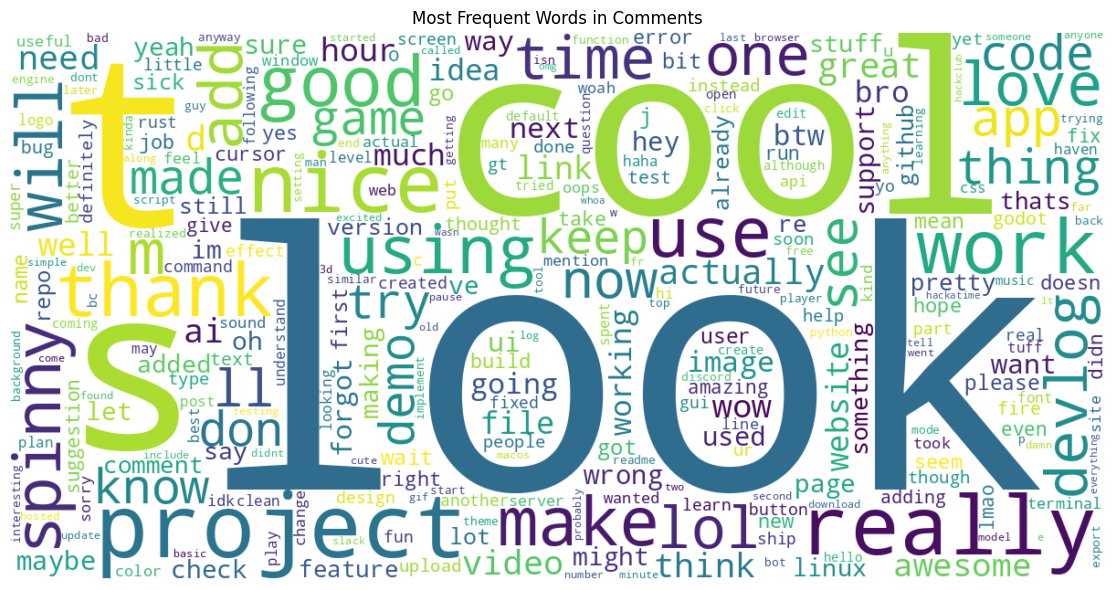

In [47]:
comment_texts = df['text'].fillna('').astype(str)
comment_texts = comment_texts[comment_texts.str.strip() != '']  # Remove empty comments

if len(comment_texts) > 0:
    corpus = ' '.join(comment_texts.tolist())
    corpus = re.sub(r"https?://\S+", " ", corpus)  # Remove URLs
    corpus = re.sub(r"[^A-Za-z0-9_+#-]+", " ", corpus)  # Keep only alphanumeric and some symbols
    corpus = re.sub(r"\s+", " ", corpus).strip().lower()  # Clean whitespace and lowercase

    if corpus:
        wc = WordCloud(
            width=1200, height=600, background_color='white',
            collocations=False, max_words=300
        ).generate(corpus)

        fig = plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Most Frequent Words in Comments')
        plt.tight_layout()

        save_matplotlib_current(name='comment_word_cloud', description='Word cloud of most frequent words in comments', friendly_name='Comment Word Cloud')
        plt.show()
    else:
        print('Comment text is empty after cleaning.')
else:
    print('No comment text found or all comments are empty.')

# Distribution of comments per devlog

How many comments do devlogs typically receive?

In [48]:
comments_per_devlog = df.groupby('devlog_id').size()

fig = px.histogram(
    comments_per_devlog, nbins=30,
    title='Distribution of Comments per Devlog',
    labels={'value': 'Comments per Devlog', 'count': 'Number of Devlogs'},
    color_discrete_sequence=['#EF553B']
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(bargap=0.05,
                  height=max(DEFAULT_HEIGHT - 20, 400),
                  xaxis_title='Comments per Devlog', yaxis_title='Number of Devlogs')
fig.show()

save_plotly(fig, name='comments_per_devlog_distribution', description='Histogram of how many comments each devlog receives', friendly_name='Comments per Devlog Distribution')

# Save all the info to an index for web stuff

In [49]:
from pandas import Timestamp

def convert_timestamps(obj):
    if isinstance(obj, dict):
        return {k: convert_timestamps(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_timestamps(v) for v in obj]
    elif isinstance(obj, Timestamp):
        return obj.isoformat()
    else:
        return obj

index_serializable = convert_timestamps(index)

index_path = EXPORT_DIR / 'index.json'
with open(index_path, 'w', encoding='utf-8') as f:
    json.dump(index_serializable, f, indent=4)
print(f'Wrote index to {index_path}')

Wrote index to /home/ajayanto/projects/SoM-Analytics/data/processed/comments/index.json
